# 02 - Data Preprocessing

## Project

Early Prediction of Student Academic Performance Using Machine Learning

## Objective

This notebook prepares the Student Performance dataset for machine
learning. The preprocessing stage includes target definition,
feature selection, train-test splitting, categorical encoding,
numerical feature scaling, and construction of a reproducible
preprocessing pipeline.

## Primary Research Design

The primary experiment aims to predict the final grade (G3) using
student demographic, family, social, behavioural, and school-related
characteristics.

The previous-period grades G1 and G2 are excluded from the primary
prediction model because they represent earlier academic performance
and have strong relationships with G3.

## Data Leakage Prevention

The dataset is split into training and testing sets before fitting
preprocessing transformations. Numerical scaling and categorical
encoding are fitted only using the training data.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
print("Preprocessing libraries loaded successfully.")

Preprocessing libraries loaded successfully.


### Load the raw dataset

In [3]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "student_performance_features.csv"
)

TARGETS_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "student_performance_targets.csv"
)

features = pd.read_csv(FEATURES_PATH)
targets = pd.read_csv(TARGETS_PATH)

df = pd.concat([features, targets], axis=1)

print("Dataset shape:", df.shape)

Dataset shape: (649, 33)


### Define the research features

In [4]:
target_column = "G3"

excluded_columns = ["G1", "G2", "G3"]

X = df.drop(columns=excluded_columns)
y = df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (649, 30)
Target shape: (649,)


### Identify feature types

In [5]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Number of numerical features: 13
Number of categorical features: 17


### Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


### Build the preprocessing transformer

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Fit only on training data

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (519, 56)
Processed testing shape: (130, 56)


### Inspect transformed features

In [10]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 56

First 20 features:
['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc'
 'num__Walc' 'num__health' 'num__absences' 'cat__school_GP'
 'cat__school_MS' 'cat__sex_F' 'cat__sex_M' 'cat__address_R'
 'cat__address_U' 'cat__famsize_GT3']


### Convert to DataFrames

In [11]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training dataset:")
display(X_train_processed_df.head())

Processed training dataset:


,num__age,num__Medu,num__Fedu,num__traveltime,num__studytime,num__failures,num__famrel,num__freetime,num__goout,num__Dalc,...,cat__activities_no,cat__activities_yes,cat__nursery_no,cat__nursery_yes,cat__higher_no,cat__higher_yes,cat__internet_no,cat__internet_yes,cat__romantic_no,cat__romantic_yes
332,0.987932,-0.437418,-0.256337,-0.754310,1.352962,-0.382133,0.068136,-0.186680,-0.196270,-0.539674,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
29,-0.629534,1.350140,1.591423,-0.754310,0.121054,-0.382133,0.068136,0.753970,1.501468,3.579309,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
302,0.987932,0.456361,-0.256337,-0.754310,1.352962,-0.382133,1.108214,-0.186680,-1.045139,-0.539674,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
286,0.179199,-0.437418,-1.180216,-0.754310,-1.110853,-0.382133,0.068136,0.753970,-1.045139,0.490072,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
554,0.179199,-1.331196,-1.180216,0.555011,-1.110853,-0.382133,-0.971942,1.694619,1.501468,0.490072,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


### Verify scaling

In [12]:
scaled_numeric_features = [
    name
    for name in feature_names
    if name.startswith("num__")
]

X_train_processed_df[scaled_numeric_features].describe().T[
    ["mean", "std"]
].head(20)

,mean,std
num__age,-7.102005e-16,1.000965
num__Medu,-5.476245e-17,1.000965
num__Fedu,1.112362e-16,1.000965
num__traveltime,1.642873e-16,1.000965
num__studytime,2.395857e-17,1.000965
num__failures,3.080388e-17,1.000965
num__famrel,1.574420e-16,1.000965
num__freetime,1.711326e-16,1.000965
num__goout,9.583428e-17,1.000965
num__Dalc,-1.351948e-16,1.000965


### Verify categorical encoding

In [13]:
encoded_categorical_features = [
    name
    for name in feature_names
    if name.startswith("cat__")
]

print(
    "Number of encoded categorical features:",
    len(encoded_categorical_features)
)

print("\nFirst 20 encoded features:")
print(encoded_categorical_features[:20])

Number of encoded categorical features: 43

First 20 encoded features:
['cat__school_GP', 'cat__school_MS', 'cat__sex_F', 'cat__sex_M', 'cat__address_R', 'cat__address_U', 'cat__famsize_GT3', 'cat__famsize_LE3', 'cat__Pstatus_A', 'cat__Pstatus_T', 'cat__Mjob_at_home', 'cat__Mjob_health', 'cat__Mjob_other', 'cat__Mjob_services', 'cat__Mjob_teacher', 'cat__Fjob_at_home', 'cat__Fjob_health', 'cat__Fjob_other', 'cat__Fjob_services', 'cat__Fjob_teacher']


# Add a preprocessing validation section

## Preprocessing Validation

The preprocessing pipeline transformed the 30 original predictor
variables into 56 machine-learning-ready features.

The 13 numerical variables were standardized using StandardScaler,
while the 17 categorical variables were transformed using one-hot
encoding.

The preprocessing transformer was fitted exclusively on the training
dataset and subsequently applied to the testing dataset using the
transform operation. This prevents information from the testing set
from influencing the learned preprocessing parameters.

In [14]:
print("=== Preprocessing Validation ===")
print(f"Original features: {X.shape[1]}")
print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Processed features: {len(feature_names)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

=== Preprocessing Validation ===
Original features: 30
Numerical features: 13
Categorical features: 17
Processed features: 56
Training samples: 519
Testing samples: 130


### Check for NaNs after transformation

In [15]:
print(
    "NaN values in processed training data:",
    np.isnan(X_train_processed).sum()
)

print(
    "NaN values in processed testing data:",
    np.isnan(X_test_processed).sum()
)

NaN values in processed training data: 0
NaN values in processed testing data: 0


### Check scaling

In [16]:
X_train_processed_df[scaled_numeric_features].describe().T[
    ["mean", "std"]
]

,mean,std
num__age,-7.102005e-16,1.000965
num__Medu,-5.476245e-17,1.000965
num__Fedu,1.112362e-16,1.000965
num__traveltime,1.642873e-16,1.000965
num__studytime,2.395857e-17,1.000965
num__failures,3.080388e-17,1.000965
num__famrel,1.574420e-16,1.000965
num__freetime,1.711326e-16,1.000965
num__goout,9.583428e-17,1.000965
num__Dalc,-1.351948e-16,1.000965


# Feature Engineering and Feature Selection

Feature engineering and feature selection are performed to identify
useful predictors of final academic performance and reduce unnecessary
or weakly informative variables.

The primary experiment excludes G1 and G2 because they represent
previous academic grades and have strong relationships with G3.

Feature selection will be investigated using statistical and
model-based approaches. Feature engineering will only be retained
when the resulting features have a meaningful interpretation and can
be evaluated experimentally.

### Mutual Information

In [17]:
from sklearn.feature_selection import mutual_info_regression

# Use training data only for feature-selection analysis
X_mi = X_train.copy()

categorical_columns = X_mi.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Convert categorical variables to integer codes
# and record them as discrete features
for column in categorical_columns:
    X_mi[column] = X_mi[column].astype("category").cat.codes

discrete_mask = [
    column in categorical_columns
    for column in X_mi.columns
]

mi_scores = mutual_info_regression(
    X_mi,
    y_train,
    discrete_features=discrete_mask,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_mi.columns,
    "Mutual Information": mi_scores
}).sort_values(
    "Mutual Information",
    ascending=False
)

mi_df

,Feature,Mutual Information
14,failures,0.104833
0,school,0.086411
20,higher,0.072710
7,Fedu,0.061949
2,age,0.061214
28,health,0.051885
6,Medu,0.047460
18,activities,0.040255
13,studytime,0.034289
3,address,0.029538


### Visualize Mutual Information

Visualization libraries loaded.


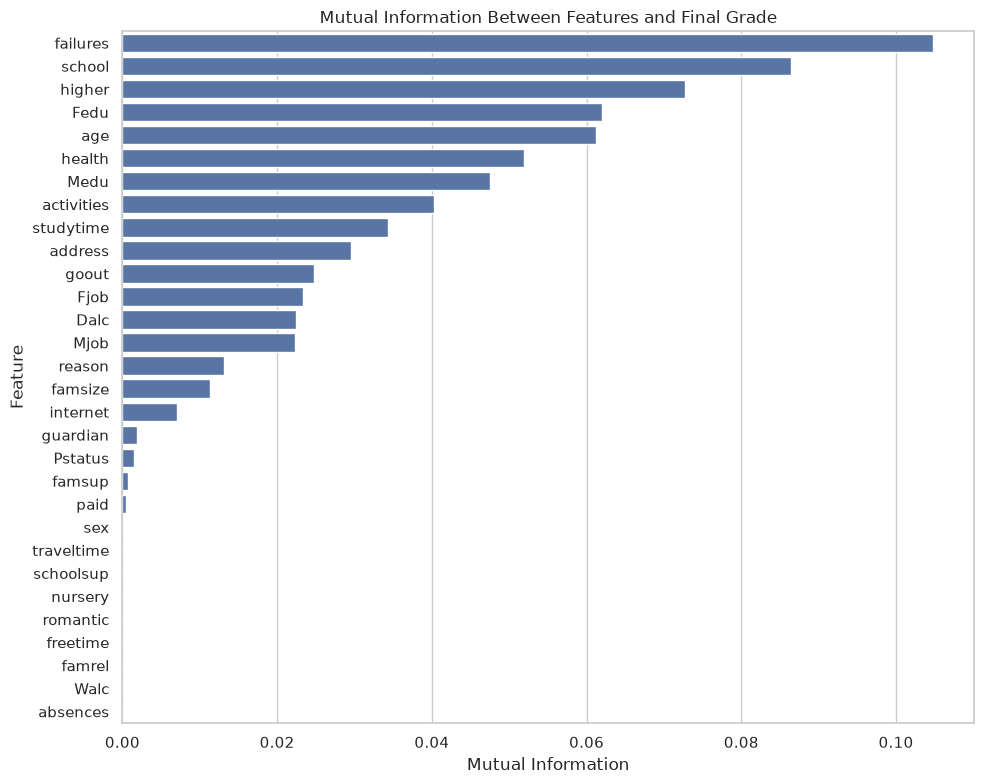

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries loaded.")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=mi_df,
    x="Mutual Information",
    y="Feature"
)

plt.title("Mutual Information Between Features and Final Grade")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Random Forest Feature Importance

In [19]:
from sklearn.ensemble import RandomForestRegressor

X_train_array = X_train_processed

rf_feature_selector = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_feature_selector.fit(
    X_train_array,
    y_train
)

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_feature_selector.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.head(20)

,Feature,Importance
5,num__failures,0.206005
12,num__absences,0.067415
2,num__Fedu,0.045641
9,num__Dalc,0.043272
10,num__Walc,0.038084
7,num__freetime,0.035639
8,num__goout,0.034396
0,num__age,0.033741
11,num__health,0.032062
4,num__studytime,0.031924


### Visualize Random Forest Importance

Visualization libraries loaded.


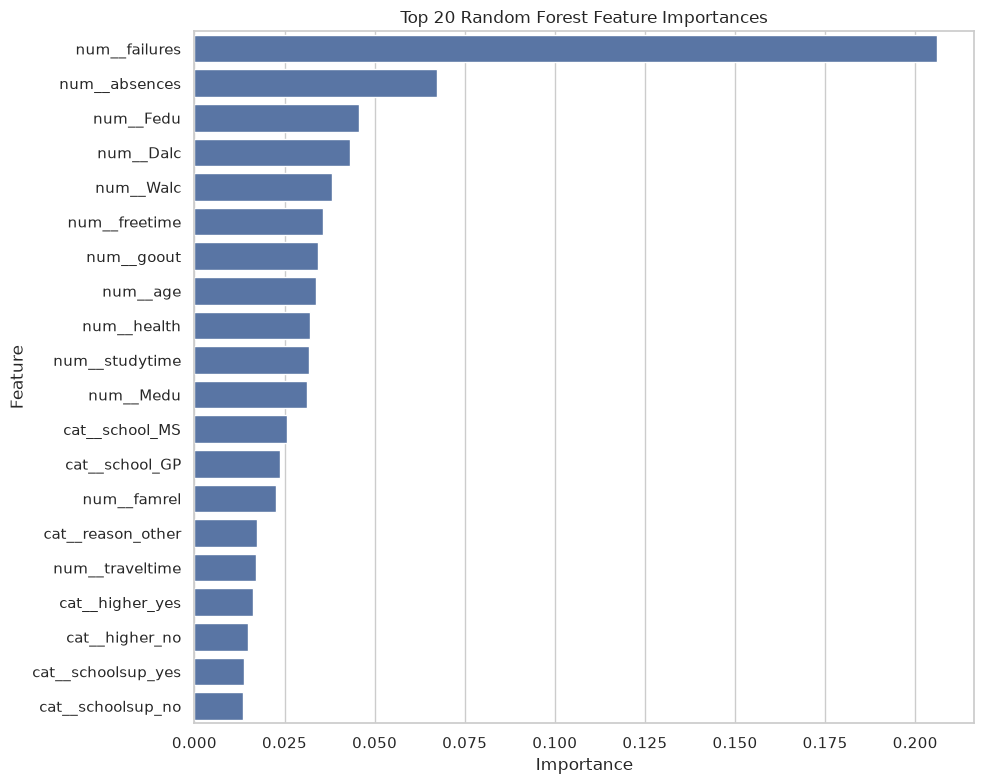

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries loaded.")

top_rf_features = rf_importance_df.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Compare the two methods

In [21]:
# Aggregate Random Forest importance back to the
# original 30 feature names.

aggregated_importance = []

for original_feature in X.columns:

    if original_feature in numeric_features:
        matching_features = [
            name
            for name in feature_names
            if name == f"num__{original_feature}"
        ]

    else:
        matching_features = [
            name
            for name in feature_names
            if name.startswith(f"cat__{original_feature}_")
        ]

    total_importance = rf_importance_df[
        rf_importance_df["Feature"].isin(matching_features)
    ]["Importance"].sum()

    aggregated_importance.append({
        "Feature": original_feature,
        "Random Forest Importance": total_importance
    })

rf_original_importance_df = pd.DataFrame(
    aggregated_importance
).sort_values(
    "Random Forest Importance",
    ascending=False
)

comparison_df = mi_df.merge(
    rf_original_importance_df,
    on="Feature",
    how="outer"
)

comparison_df = comparison_df.sort_values(
    "Random Forest Importance",
    ascending=False
)

comparison_df

,Feature,Mutual Information,Random Forest Importance
11,failures,0.104833,0.206005
7,absences,0.000000,0.067415
25,school,0.086411,0.049561
23,reason,0.013077,0.048635
1,Fedu,0.061949,0.045641
0,Dalc,0.022418,0.043272
4,Mjob,0.022329,0.039140
6,Walc,0.000000,0.038084
15,freetime,0.000000,0.035639
16,goout,0.024738,0.034396


## Feature Engineering

### 1. Parental education

In [22]:
X_engineered = X.copy()

X_engineered["parent_education_avg"] = (
    X_engineered["Medu"] +
    X_engineered["Fedu"]
) / 2

### 2. Alcohol consumption

In [23]:
X_engineered["alcohol_consumption"] = (
    X_engineered["Dalc"] +
    X_engineered["Walc"]
) / 2

### 3. Social activity

In [24]:
X_engineered["social_activity"] = (
    X_engineered["freetime"] +
    X_engineered["goout"]
) / 2

### Check the engineered features

In [25]:
X_engineered[
    [
        "parent_education_avg",
        "alcohol_consumption",
        "social_activity"
    ]
].describe()

,parent_education_avg,alcohol_consumption,social_activity
count,649.000000,649.000000,649.000000
mean,2.410632,1.891371,3.182589
std,1.014035,0.996206,0.914234
min,0.000000,1.000000,1.000000
25%,1.500000,1.000000,2.500000
50%,2.500000,1.500000,3.000000
75%,3.000000,2.500000,4.000000
max,4.000000,5.000000,5.000000


In [26]:
engineered_train = X_engineered.loc[X_train.index]

engineered_correlations = pd.DataFrame({
    "Feature": [
        "parent_education_avg",
        "alcohol_consumption",
        "social_activity"
    ],
    "Correlation_with_G3": [
        engineered_train["parent_education_avg"].corr(y_train),
        engineered_train["alcohol_consumption"].corr(y_train),
        engineered_train["social_activity"].corr(y_train)
    ]
}).sort_values(
    "Correlation_with_G3",
    key=abs,
    ascending=False
)

engineered_correlations

,Feature,Correlation_with_G3
0,parent_education_avg,0.253435
1,alcohol_consumption,-0.228044
2,social_activity,-0.124853


### Feature Selection Candidates

In [27]:
mi_df.head(10)

,Feature,Mutual Information
14,failures,0.104833
0,school,0.086411
20,higher,0.072710
7,Fedu,0.061949
2,age,0.061214
28,health,0.051885
6,Medu,0.047460
18,activities,0.040255
13,studytime,0.034289
3,address,0.029538


In [28]:
rf_importance_df.head(20)

,Feature,Importance
5,num__failures,0.206005
12,num__absences,0.067415
2,num__Fedu,0.045641
9,num__Dalc,0.043272
10,num__Walc,0.038084
7,num__freetime,0.035639
8,num__goout,0.034396
0,num__age,0.033741
11,num__health,0.032062
4,num__studytime,0.031924


# Baseline Machine Learning Model

A Linear Regression model is used as the initial baseline for predicting
the final grade (G3). The baseline provides a reference point against
which more complex machine learning models can be compared.

The baseline uses the complete set of preprocessed early-prediction
features.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_processed,
    y_train
)

# Test predictions
y_pred_baseline = baseline_model.predict(
    X_test_processed
)

baseline_mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

baseline_r2 = r2_score(
    y_test,
    y_pred_baseline
)

# Training predictions
baseline_train_pred = baseline_model.predict(
    X_train_processed
)

baseline_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        baseline_train_pred
    )
)

# Store baseline results
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2],
    "Training RMSE": [baseline_train_rmse]
})

baseline_results

,Model,MAE,RMSE,R2,Training RMSE
0,Linear Regression,2.156382,2.86178,0.16017,2.539222


### Cross-validation baseline

In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

cv_rmse_scores = np.sqrt(
    -cross_val_score(
        baseline_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("5-Fold Cross-Validation RMSE Scores:")
print(cv_rmse_scores)

print("\nMean CV RMSE:", cv_rmse_scores.mean())
print("Std CV RMSE:", cv_rmse_scores.std())

5-Fold Cross-Validation RMSE Scores:
[2.46952591 2.81851836 2.82685086 3.31883864 2.51496784]

Mean CV RMSE: 2.789740320505882
Std CV RMSE: 0.3033768583020585


## Baseline Interpretation

The Linear Regression model provides the initial benchmark for the
early prediction task.

On the held-out test set, the model achieved an MAE of approximately
2.16 grade points, an RMSE of approximately 2.86 grade points, and an
R² of approximately 0.16.

Five-fold cross-validation is used to obtain a more reliable estimate
of model performance on unseen training folds. The preprocessing
operations are included inside the cross-validation pipeline so that
scaling and categorical encoding are fitted independently within each
training fold, preventing data leakage.

More complex machine learning models will be compared against this
baseline to determine whether nonlinear models provide improved
predictive performance.

# Decision Tree Regression

A Decision Tree Regressor is evaluated as a nonlinear alternative to
the Linear Regression baseline. Decision trees can model nonlinear
relationships and interactions between predictors without requiring
a linear relationship between the input variables and final grade.

The preprocessing steps remain inside the machine learning pipeline
to prevent data leakage during cross-validation.

In [31]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

y_pred_dt = decision_tree_pipeline.predict(
    X_test
)

dt_mae = mean_absolute_error(
    y_test,
    y_pred_dt
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt
    )
)

dt_r2 = r2_score(
    y_test,
    y_pred_dt
)

decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "MAE": [dt_mae],
    "RMSE": [dt_rmse],
    "R2": [dt_r2]
})

decision_tree_results

,Model,MAE,RMSE,R2
0,Decision Tree,2.861538,3.798785,-0.479818


### Decision Tree Cross-Validation

In [32]:
dt_cv_rmse_scores = np.sqrt(
    -cross_val_score(
        decision_tree_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("Decision Tree 5-Fold CV RMSE Scores:")
print(dt_cv_rmse_scores)

print("\nMean CV RMSE:", dt_cv_rmse_scores.mean())
print("Std CV RMSE:", dt_cv_rmse_scores.std())

Decision Tree 5-Fold CV RMSE Scores:
[3.81293346 3.68729628 3.92967018 3.55181427 3.93885302]

Mean CV RMSE: 3.784113440116279
Std CV RMSE: 0.14785003264153093


### Check for overfitting

In [33]:
dt_train_pred = decision_tree_pipeline.predict(X_train)

dt_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        dt_train_pred
    )
)

print("Decision Tree Training RMSE:", dt_train_rmse)
print("Decision Tree Test RMSE:", dt_rmse)
print("Decision Tree CV RMSE:", dt_cv_rmse_scores.mean())

Decision Tree Training RMSE: 0.0
Decision Tree Test RMSE: 3.7987852309349144
Decision Tree CV RMSE: 3.784113440116279


## Regularized Decision Tree

The unrestricted Decision Tree achieved zero training error but showed
substantially higher validation and test errors. This indicates
overfitting.

A regularized Decision Tree is therefore evaluated by limiting the
maximum tree depth. The objective is to determine whether reducing
model complexity improves generalization.

In [34]:
from sklearn.tree import DecisionTreeRegressor

regularized_dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

regularized_dt_pipeline.fit(
    X_train,
    y_train
)

y_pred_regularized_dt = regularized_dt_pipeline.predict(
    X_test
)

regularized_dt_mae = mean_absolute_error(
    y_test,
    y_pred_regularized_dt
)

regularized_dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_regularized_dt
    )
)

regularized_dt_r2 = r2_score(
    y_test,
    y_pred_regularized_dt
)

regularized_dt_results = pd.DataFrame({
    "Model": ["Decision Tree (max_depth=5)"],
    "MAE": [regularized_dt_mae],
    "RMSE": [regularized_dt_rmse],
    "R2": [regularized_dt_r2]
})

regularized_dt_results

,Model,MAE,RMSE,R2
0,Decision Tree (max_depth=5),2.372037,3.15942,-0.023608


In [35]:
regularized_dt_cv_rmse = np.sqrt(
    -cross_val_score(
        regularized_dt_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("Regularized Decision Tree CV RMSE:")
print(regularized_dt_cv_rmse)

print("\nMean CV RMSE:", regularized_dt_cv_rmse.mean())
print("Std CV RMSE:", regularized_dt_cv_rmse.std())

Regularized Decision Tree CV RMSE:
[3.23898609 3.0773455  3.46542964 3.36175914 2.84787222]

Mean CV RMSE: 3.198278518018138
Std CV RMSE: 0.2177898567722454


In [36]:
regularized_dt_train_pred = regularized_dt_pipeline.predict(X_train)

regularized_dt_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        regularized_dt_train_pred
    )
)

print("Training RMSE:", regularized_dt_train_rmse)
print("Test RMSE:", regularized_dt_rmse)
print("CV RMSE:", regularized_dt_cv_rmse.mean())

Training RMSE: 2.215129256734678
Test RMSE: 3.1594198754996903
CV RMSE: 3.198278518018138


# Random Forest Regression

Random Forest Regression is evaluated as an ensemble-based nonlinear
model. It combines multiple decision trees and averages their
predictions, which can reduce the variance and overfitting associated
with a single decision tree.

The model is evaluated using the same train/test split and
leakage-safe five-fold cross-validation strategy used for the previous
models.

In [37]:
from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_pipeline.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "R2": [rf_r2]
})

random_forest_results

,Model,MAE,RMSE,R2
0,Random Forest,2.050462,2.812826,0.188657


### Random Forest Cross-Validation

In [38]:
rf_cv_rmse_scores = np.sqrt(
    -cross_val_score(
        random_forest_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("Random Forest 5-Fold CV RMSE:")
print(rf_cv_rmse_scores)

print("\nMean CV RMSE:", rf_cv_rmse_scores.mean())
print("Std CV RMSE:", rf_cv_rmse_scores.std())

Random Forest 5-Fold CV RMSE:
[2.59547908 2.49248141 2.88017068 3.24678255 2.40429315]

Mean CV RMSE: 2.723841372144802
Std CV RMSE: 0.306601271474008


### Random Forest overfitting check

In [39]:
rf_train_pred = random_forest_pipeline.predict(X_train)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_pred
    )
)

print("Random Forest Training RMSE:", rf_train_rmse)
print("Random Forest Test RMSE:", rf_rmse)
print("Random Forest CV RMSE:", rf_cv_rmse_scores.mean())

Random Forest Training RMSE: 1.0103005672263439
Random Forest Test RMSE: 2.812825844372387
Random Forest CV RMSE: 2.723841372144802


### First model comparison table

In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Decision Tree (max_depth=5)",
        "Random Forest"
    ],
    "Test MAE": [
        baseline_mae,
        dt_mae,
        regularized_dt_mae,
        rf_mae
    ],
    "Test RMSE": [
        baseline_rmse,
        dt_rmse,
        regularized_dt_rmse,
        rf_rmse
    ],
    "Test R2": [
        baseline_r2,
        dt_r2,
        regularized_dt_r2,
        rf_r2
    ],
    "Training RMSE": [
        np.nan,
        dt_train_rmse,
        regularized_dt_train_rmse,
        rf_train_rmse
    ],
    "CV RMSE": [
        cv_rmse_scores.mean(),
        dt_cv_rmse_scores.mean(),
        regularized_dt_cv_rmse.mean(),
        rf_cv_rmse_scores.mean()
    ],
    "CV RMSE Std": [
        cv_rmse_scores.std(),
        dt_cv_rmse_scores.std(),
        regularized_dt_cv_rmse.std(),
        rf_cv_rmse_scores.std()
    ]
})

model_comparison = model_comparison.sort_values(
    "Test RMSE"
).reset_index(drop=True)

model_comparison

,Model,Test MAE,Test RMSE,Test R2,Training RMSE,CV RMSE,CV RMSE Std
0,Random Forest,2.050462,2.812826,0.188657,1.010301,2.723841,0.306601
1,Linear Regression,2.156382,2.861780,0.160170,NaN,2.789740,0.303377
2,Decision Tree (max_depth=5),2.372037,3.159420,-0.023608,2.215129,3.198279,0.217790
3,Decision Tree,2.861538,3.798785,-0.479818,0.000000,3.784113,0.147850


## Initial Model Comparison

Four regression approaches were evaluated: Linear Regression,
Decision Tree, a regularized Decision Tree, and Random Forest.

The unrestricted Decision Tree showed severe overfitting, with a
training RMSE of zero but substantially higher test and cross-validation
errors.

Limiting the Decision Tree depth reduced overfitting and improved
generalization, but its performance remained weaker than the Linear
Regression baseline.

Random Forest produced the strongest initial test performance, with
the lowest MAE and RMSE and the highest R² among the evaluated models.
Its cross-validation RMSE was also lower than the Linear Regression
baseline.

However, the Random Forest has not yet undergone hyperparameter tuning
or feature-set comparison. Therefore, it is considered the current
best-performing candidate rather than the final selected model.

### Reduced Feature Set

In [41]:
selected_features = [
    "failures",
    "school",
    "higher",
    "Fedu",
    "age",
    "health",
    "Medu",
    "studytime",
    "absences",
    "reason"
]

### Reduced Dataset

In [42]:
X_selected = X[selected_features]

X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

print("Selected feature count:", X_selected.shape[1])
print("Selected training shape:", X_selected_train.shape)
print("Selected testing shape:", X_selected_test.shape)

Selected feature count: 10
Selected training shape: (519, 10)
Selected testing shape: (130, 10)


### Build a NEW preprocessing pipeline

In [43]:
selected_numeric_features = X_selected.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

selected_categorical_features = X_selected.select_dtypes(
    include=["object", "string"]
).columns.tolist()

selected_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("scaler", StandardScaler())
                ]
            ),
            selected_numeric_features
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            selected_categorical_features
        )
    ]
)

print("Selected numerical features:", selected_numeric_features)
print("Selected categorical features:", selected_categorical_features)

Selected numerical features: ['failures', 'Fedu', 'age', 'health', 'Medu', 'studytime', 'absences']
Selected categorical features: ['school', 'higher', 'reason']


### Selected-feature Random Forest

In [44]:
selected_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", selected_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [45]:
selected_rf_pipeline.fit(
    X_selected_train,
    y_selected_train
)

selected_rf_pred = selected_rf_pipeline.predict(
    X_selected_test
)

selected_rf_mae = mean_absolute_error(
    y_selected_test,
    selected_rf_pred
)

selected_rf_rmse = np.sqrt(
    mean_squared_error(
        y_selected_test,
        selected_rf_pred
    )
)

selected_rf_r2 = r2_score(
    y_selected_test,
    selected_rf_pred
)

print("Selected Feature Random Forest")
print("MAE:", selected_rf_mae)
print("RMSE:", selected_rf_rmse)
print("R²:", selected_rf_r2)

Selected Feature Random Forest
MAE: 2.114891330891331
RMSE: 2.9035973360128557
R²: 0.13544677570965447


### Cross-validation

In [46]:
selected_rf_cv_scores = np.sqrt(
    -cross_val_score(
        selected_rf_pipeline,
        X_selected_train,
        y_selected_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("Selected Feature RF CV RMSE:")
print(selected_rf_cv_scores)

print("\nMean CV RMSE:", selected_rf_cv_scores.mean())
print("Std CV RMSE:", selected_rf_cv_scores.std())

Selected Feature RF CV RMSE:
[2.82404304 2.69818869 3.02289583 3.37346228 2.53903682]

Mean CV RMSE: 2.8915253289456775
Std CV RMSE: 0.28834094282180767


### Compare Full vs Selected

In [47]:
feature_set_comparison = pd.DataFrame({
    "Feature Set": [
        "All 30 original features",
        "Selected 10 features"
    ],
    "Number of Original Features": [
        X.shape[1],
        X_selected.shape[1]
    ],
    "Test MAE": [
        rf_mae,
        selected_rf_mae
    ],
    "Test RMSE": [
        rf_rmse,
        selected_rf_rmse
    ],
    "Test R2": [
        rf_r2,
        selected_rf_r2
    ],
    "CV RMSE": [
        rf_cv_rmse_scores.mean(),
        selected_rf_cv_scores.mean()
    ],
    "CV RMSE Std": [
        rf_cv_rmse_scores.std(),
        selected_rf_cv_scores.std()
    ]
})

feature_set_comparison

,Feature Set,Number of Original Features,Test MAE,Test RMSE,Test R2,CV RMSE,CV RMSE Std
0,All 30 original features,30,2.050462,2.812826,0.188657,2.723841,0.306601
1,Selected 10 features,10,2.114891,2.903597,0.135447,2.891525,0.288341


## Feature Selection Evaluation

A reduced feature set containing 10 variables was evaluated against the
complete set of 30 early-prediction features using the Random Forest
model.

The complete feature set achieved better performance on the held-out
test set, with an RMSE of approximately 2.81 compared with 2.90 for the
reduced feature set. The complete feature set also achieved a higher R²
(approximately 0.189 compared with 0.135).

The five-fold cross-validation results showed the same pattern. The
complete feature set achieved a mean CV RMSE of approximately 2.72,
while the reduced feature set achieved approximately 2.89.

Therefore, attribute subset selection did not improve predictive
performance for this dataset. The complete set of 30 early-prediction
features is retained for subsequent model development.

This experiment demonstrates that feature selection was evaluated
empirically rather than assuming that reducing the number of attributes
would automatically improve the model.

## Engineered Feature Evaluation

Three domain-informed features were created:

- `parent_education_avg`: average parental education level.
- `alcohol_consumption`: average weekday and weekend alcohol consumption.
- `social_activity`: average free time and going-out frequency.

These features are evaluated by adding them to the complete original
feature set and comparing the resulting Random Forest performance with
the original 30-feature model.

In [48]:
X_engineered_full = X.copy()

X_engineered_full["parent_education_avg"] = (
    X_engineered_full["Medu"] +
    X_engineered_full["Fedu"]
) / 2

X_engineered_full["alcohol_consumption"] = (
    X_engineered_full["Dalc"] +
    X_engineered_full["Walc"]
) / 2

X_engineered_full["social_activity"] = (
    X_engineered_full["freetime"] +
    X_engineered_full["goout"]
) / 2

print("Original feature count:", X.shape[1])
print("Engineered feature count:", X_engineered_full.shape[1])

Original feature count: 30
Engineered feature count: 33


### Train/test split

In [49]:
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_engineered_full,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_eng_train.shape)
print("Testing shape:", X_eng_test.shape)

Training shape: (519, 33)
Testing shape: (130, 33)


### Build preprocessing pipeline

In [50]:
eng_numeric_features = X_engineered_full.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

eng_categorical_features = X_engineered_full.select_dtypes(
    include=["object", "string"]
).columns.tolist()

engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("scaler", StandardScaler())
                ]
            ),
            eng_numeric_features
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            eng_categorical_features
        )
    ]
)

print("Numerical features:", len(eng_numeric_features))
print("Categorical features:", len(eng_categorical_features))

Numerical features: 16
Categorical features: 17


### Engineered Random Forest

In [51]:
engineered_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", engineered_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

engineered_rf_pipeline.fit(
    X_eng_train,
    y_eng_train
)

engineered_rf_pred = engineered_rf_pipeline.predict(
    X_eng_test
)

engineered_rf_mae = mean_absolute_error(
    y_eng_test,
    engineered_rf_pred
)

engineered_rf_rmse = np.sqrt(
    mean_squared_error(
        y_eng_test,
        engineered_rf_pred
    )
)

engineered_rf_r2 = r2_score(
    y_eng_test,
    engineered_rf_pred
)

print("Engineered Feature Random Forest")
print("MAE:", engineered_rf_mae)
print("RMSE:", engineered_rf_rmse)
print("R²:", engineered_rf_r2)

Engineered Feature Random Forest
MAE: 2.0665128205128203
RMSE: 2.843411397611745
R²: 0.17091633967891806


### Cross-validation

In [52]:
engineered_rf_cv_scores = np.sqrt(
    -cross_val_score(
        engineered_rf_pipeline,
        X_eng_train,
        y_eng_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

print("Engineered Feature RF CV RMSE:")
print(engineered_rf_cv_scores)

print("\nMean CV RMSE:", engineered_rf_cv_scores.mean())
print("Std CV RMSE:", engineered_rf_cv_scores.std())

Engineered Feature RF CV RMSE:
[2.57437817 2.4748055  2.87514268 3.1881788  2.35697869]

Mean CV RMSE: 2.6938967689892133
Std CV RMSE: 0.3009864706017378


### Compare the feature strategies

In [53]:
engineered_feature_comparison = pd.DataFrame({
    "Feature Strategy": [
        "All 30 original features",
        "Selected 10 features",
        "30 original + 3 engineered"
    ],
    "Feature Count": [
        30,
        10,
        33
    ],
    "Test MAE": [
        rf_mae,
        selected_rf_mae,
        engineered_rf_mae
    ],
    "Test RMSE": [
        rf_rmse,
        selected_rf_rmse,
        engineered_rf_rmse
    ],
    "Test R2": [
        rf_r2,
        selected_rf_r2,
        engineered_rf_r2
    ],
    "CV RMSE": [
        rf_cv_rmse_scores.mean(),
        selected_rf_cv_scores.mean(),
        engineered_rf_cv_scores.mean()
    ],
    "CV RMSE Std": [
        rf_cv_rmse_scores.std(),
        selected_rf_cv_scores.std(),
        engineered_rf_cv_scores.std()
    ]
})

engineered_feature_comparison.sort_values(
    "CV RMSE"
).reset_index(drop=True)

,Feature Strategy,Feature Count,Test MAE,Test RMSE,Test R2,CV RMSE,CV RMSE Std
0,30 original + 3 engineered,33,2.066513,2.843411,0.170916,2.693897,0.300986
1,All 30 original features,30,2.050462,2.812826,0.188657,2.723841,0.306601
2,Selected 10 features,10,2.114891,2.903597,0.135447,2.891525,0.288341


## Engineered Feature Comparison Interpretation

The engineered feature experiment compared the original 30-feature
representation with a 33-feature representation containing three
domain-informed features: `parent_education_avg`,
`alcohol_consumption`, and `social_activity`.

The engineered feature model achieved a slightly lower mean
five-fold cross-validation RMSE (approximately 2.69) compared with
the original feature model (approximately 2.72). However, the
engineered feature model produced slightly worse held-out test
performance, with an RMSE of approximately 2.84 compared with 2.81
for the original feature model.

The original 30-feature model also achieved the highest test R²
(approximately 0.189).

Therefore, the original 30-feature representation is retained as the
primary feature strategy for subsequent model development. The
engineered feature experiment is retained as an alternative
experiment and demonstrates that adding domain-informed features does
not necessarily improve final predictive performance.

# Random Forest Hyperparameter Tuning

Random Forest was identified as the strongest initial model based on
the comparison of Linear Regression, Decision Tree, regularized
Decision Tree, and Random Forest.

Hyperparameter tuning is performed to determine whether adjusting
model complexity and ensemble parameters can improve generalization.

The original 30-feature representation is used because it produced
the strongest held-out test performance during the feature strategy
comparison.

### Define parameter grid

In [54]:
from sklearn.model_selection import GridSearchCV

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

### Use RandomizedSearchCV

In [55]:
from sklearn.model_selection import RandomizedSearchCV

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [0.5, 0.75, 1.0]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

### Run tuning

In [56]:
rf_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': [0.5, 0.75, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maxim

### Get best parameters

In [57]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_random_search.best_score_)

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 10}

Best CV RMSE:
2.632484263144203


### Evaluate tuned model

In [58]:
tuned_rf_model = rf_random_search.best_estimator_

# Test predictions
tuned_rf_pred = tuned_rf_model.predict(
    X_test
)

tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_pred
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_pred
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_pred
)

# Training predictions for overfitting analysis
tuned_rf_train_pred = tuned_rf_model.predict(
    X_train
)

tuned_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_rf_train_pred
    )
)

print("Tuned Random Forest")
print("Test MAE:", tuned_rf_mae)
print("Test RMSE:", tuned_rf_rmse)
print("Test R²:", tuned_rf_r2)
print("Training RMSE:", tuned_rf_train_rmse)
print("CV RMSE:", -rf_random_search.best_score_)

Tuned Random Forest
Test MAE: 2.0116423695543886
Test RMSE: 2.764395091442408
Test R²: 0.2163553327292672
Training RMSE: 1.8642757919403292
CV RMSE: 2.632484263144203


## Hyperparameter Tuning Interpretation

Randomized hyperparameter search was used to evaluate different
Random Forest configurations using five-fold cross-validation.

The best configuration used 300 trees, a maximum depth of 10,
a minimum samples split of 2, a minimum samples leaf of 4, and
50% of the features for each split.

The tuned Random Forest improved upon the initial Random Forest.
Test RMSE decreased from approximately 2.81 to 2.76, while R²
increased from approximately 0.189 to 0.216. The mean cross-validation
RMSE also improved from approximately 2.72 to 2.63.

Training RMSE is additionally examined to determine whether the tuned
model is overfitting. The difference between training, cross-validation,
and held-out test performance is considered when selecting the final
model.

### Compare tuned vs initial Random Forest

In [59]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Test MAE": [
        rf_mae,
        tuned_rf_mae
    ],
    "Test RMSE": [
        rf_rmse,
        tuned_rf_rmse
    ],
    "Test R2": [
        rf_r2,
        tuned_rf_r2
    ],
    "CV RMSE": [
        rf_cv_rmse_scores.mean(),
        -rf_random_search.best_score_
    ]
})

tuning_comparison

,Model,Test MAE,Test RMSE,Test R2,CV RMSE
0,Initial Random Forest,2.050462,2.812826,0.188657,2.723841
1,Tuned Random Forest,2.011642,2.764395,0.216355,2.632484


## Model Selection Based on Cross-Validation

Model selection is performed using five-fold cross-validation on the
training dataset. The test set is not used during cross-validation or
hyperparameter optimization.

Based on the cross-validation results, the tuned Random Forest achieved
the lowest mean RMSE among the evaluated regression models.

Therefore, the tuned Random Forest is selected as the final regression
model based on cross-validation performance. The test-set results are
then reported as the final assessment of this selected model.

In [60]:
cv_model_selection = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Decision Tree (max_depth=5)",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV RMSE": [
        cv_rmse_scores.mean(),
        dt_cv_rmse_scores.mean(),
        regularized_dt_cv_rmse.mean(),
        rf_cv_rmse_scores.mean(),
        -rf_random_search.best_score_
    ],
    "CV RMSE Std": [
        cv_rmse_scores.std(),
        dt_cv_rmse_scores.std(),
        regularized_dt_cv_rmse.std(),
        rf_cv_rmse_scores.std(),
        "Not directly available from RandomizedSearchCV best_score_"
    ]
})

cv_model_selection.sort_values(
    "Mean CV RMSE"
).reset_index(drop=True)

,Model,Mean CV RMSE,CV RMSE Std
0,Tuned Random Forest,2.632484,Not directly available from RandomizedSearchCV...
1,Random Forest,2.723841,0.306601
2,Linear Regression,2.789740,0.303377
3,Decision Tree (max_depth=5),3.198279,0.21779
4,Decision Tree,3.784113,0.14785


### Final Comparison

In [61]:
final_regression_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Decision Tree (max_depth=5)",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Test MAE": [
        baseline_mae,
        dt_mae,
        regularized_dt_mae,
        rf_mae,
        tuned_rf_mae
    ],
    "Test RMSE": [
        baseline_rmse,
        dt_rmse,
        regularized_dt_rmse,
        rf_rmse,
        tuned_rf_rmse
    ],
    "Test R2": [
        baseline_r2,
        dt_r2,
        regularized_dt_r2,
        rf_r2,
        tuned_rf_r2
    ],
    "Training RMSE": [
        baseline_train_rmse,
        dt_train_rmse,
        regularized_dt_train_rmse,
        rf_train_rmse,
        tuned_rf_train_rmse
    ],
    "CV RMSE": [
        cv_rmse_scores.mean(),
        dt_cv_rmse_scores.mean(),
        regularized_dt_cv_rmse.mean(),
        rf_cv_rmse_scores.mean(),
        -rf_random_search.best_score_
    ]
})

final_regression_comparison.sort_values(
    "Test RMSE"
).reset_index(drop=True)

,Model,Test MAE,Test RMSE,Test R2,Training RMSE,CV RMSE
0,Tuned Random Forest,2.011642,2.764395,0.216355,1.864276,2.632484
1,Random Forest,2.050462,2.812826,0.188657,1.010301,2.723841
2,Linear Regression,2.156382,2.861780,0.160170,2.539222,2.789740
3,Decision Tree (max_depth=5),2.372037,3.159420,-0.023608,2.215129,3.198279
4,Decision Tree,2.861538,3.798785,-0.479818,0.000000,3.784113


## Regression Model Selection

Five regression approaches were evaluated during the study.

The unrestricted Decision Tree demonstrated severe overfitting,
while limiting its maximum depth reduced the overfitting but did not
produce competitive predictive performance.

Linear Regression provided a useful baseline. Random Forest produced
better predictive performance than the baseline, and hyperparameter
tuning further improved the Random Forest model.

The tuned Random Forest achieved the lowest test RMSE and MAE and the
highest test R² among the evaluated regression models. It also achieved
the lowest mean cross-validation RMSE.

Therefore, the tuned Random Forest is selected as the final regression
model for predicting students' final grade (G3).

### Final model selection

In [62]:
best_model_name = cv_model_selection.sort_values(
    "Mean CV RMSE"
).iloc[0]["Model"]

print("Selected final regression model:")
print(best_model_name)

Selected final regression model:
Tuned Random Forest


In [63]:
final_test_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "MAE": [tuned_rf_mae],
    "RMSE": [tuned_rf_rmse],
    "R2": [tuned_rf_r2],
    "Training RMSE": [tuned_rf_train_rmse],
    "CV RMSE": [-rf_random_search.best_score_]
})

final_test_results

,Model,MAE,RMSE,R2,Training RMSE,CV RMSE
0,Tuned Random Forest,2.011642,2.764395,0.216355,1.864276,2.632484


## Final Regression Evaluation

After model selection using five-fold cross-validation on the training
data, the tuned Random Forest was selected as the final regression
model.

The held-out test set is used to report the final predictive
performance of the selected model. The test set was not used during
cross-validation or RandomizedSearchCV hyperparameter optimization.

Earlier test-set results were examined during the exploratory model
comparison stage; therefore, this evaluation is reported as the final
test-set assessment of the selected model rather than as a completely
untouched external validation.